Лабораторна робота №8

Виконав: Верещака Олександр ПР-2-2
Варіант №1

### Хід роботи

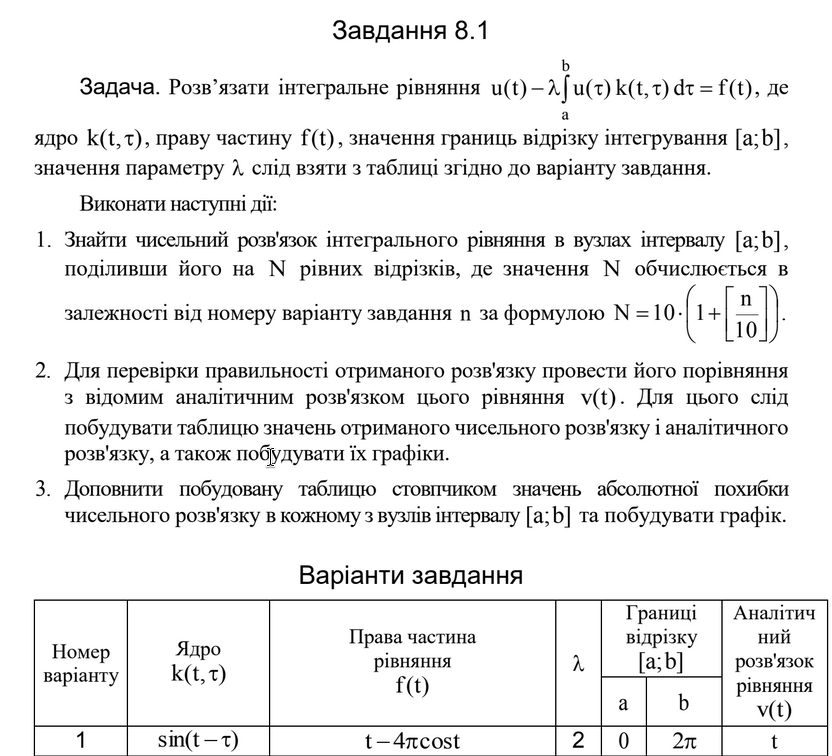

Завдання 8.1 (Варіант 1) - Розв'язок інтегрального рівняння Фредгольма
 Вузол t  Чисельний розв'язок u(t)  Аналітичний розв'язок v(t)  Абсолютна похибка
0.000000                 -0.010281                    0.000000           0.010281
0.628319                  0.582031                    0.628319           0.046287
1.256637                  1.192024                    1.256637           0.064613
1.884956                  1.826696                    1.884956           0.058259
2.513274                  2.483622                    2.513274           0.029652
3.141593                  3.151874                    3.141593           0.010281
3.769911                  3.816199                    3.769911           0.046287
4.398230                  4.462843                    4.398230           0.064613
5.026548                  5.084808                    5.026548           0.058259
5.654867                  5.684519                    5.654867           0.029652
6.283185                  6

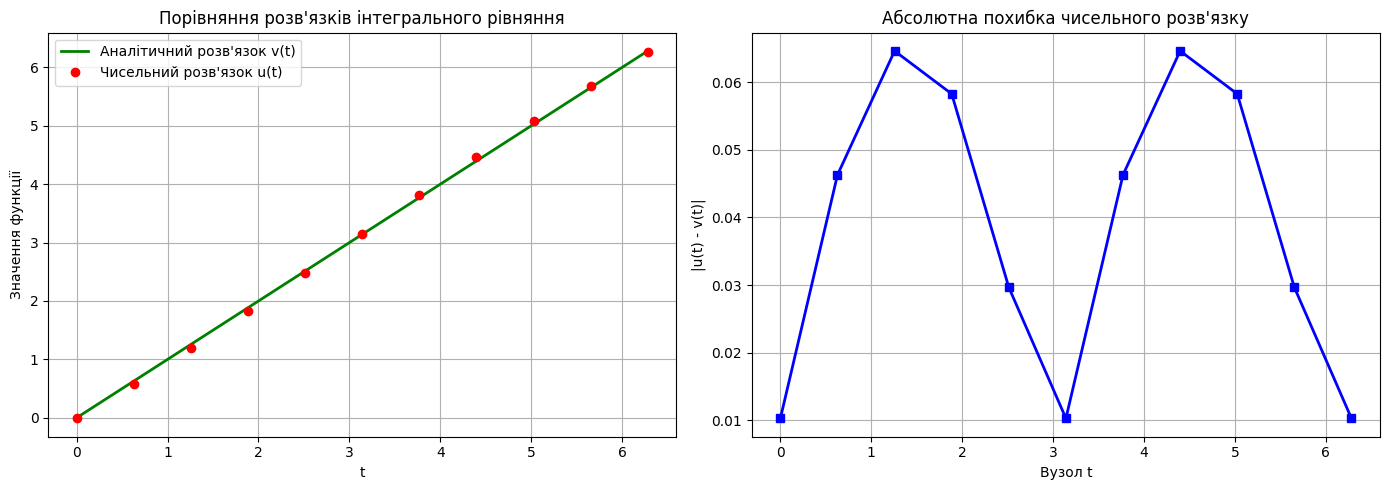

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ==========================================
# Вхідні дані (Завдання 8.1, Варіант 1)
# ==========================================
n_var = 1
# Формула N = 10 * (1 + [n/10]). У Python цілочисельне ділення це //
N = 10 * (1 + n_var // 10)  
a = 0.0
b = 2 * np.pi
lam = 2.0

def k_func(t, tau):
    """Ядро інтегрального рівняння"""
    return np.sin(t - tau)

def f_func(t):
    """Права частина рівняння"""
    return t - 4 * np.pi * np.cos(t)

def v_exact(t):
    """Відомий аналітичний розв'язок"""
    return t

# ==========================================
# 1. Формування сітки та ваг (Метод трапецій)
# ==========================================
t_nodes = np.linspace(a, b, N + 1)
h = (b - a) / N

# Задаємо ваги для квадратурної формули трапецій
w = np.full(N + 1, h)
w[0] = h / 2
w[-1] = h / 2

# ==========================================
# 2. Зведення до СЛАР: (I - lambda * K * W) * u = F
# ==========================================
# Одинична матриця I
I = np.eye(N + 1)

# Формуємо матрицю K з ядра рівняння
K_mat = np.zeros((N + 1, N + 1))
for i in range(N + 1):
    for j in range(N + 1):
        K_mat[i, j] = k_func(t_nodes[i], t_nodes[j])

# Будуємо головну матрицю системи A. 
# K_mat * w виконує множення кожного j-го стовпця на вагу w[j]
A = I - lam * K_mat * w

# Вектор правої частини
F = f_func(t_nodes)

# ==========================================
# 3. Розв'язання та обчислення похибки
# ==========================================
# Знаходимо чисельний розв'язок (вектор u)
u_num = np.linalg.solve(A, F)

# Обчислюємо точний аналітичний розв'язок для порівняння
v_ana = v_exact(t_nodes)

# Обчислюємо абсолютну похибку
abs_error = np.abs(u_num - v_ana)

# ==========================================
# 4. Створення порівняльної таблиці
# ==========================================
df = pd.DataFrame({
    "Вузол t": t_nodes,
    "Чисельний розв'язок u(t)": u_num,
    "Аналітичний розв'язок v(t)": v_ana,
    "Абсолютна похибка": abs_error
})

print("Завдання 8.1 (Варіант 1) - Розв'язок інтегрального рівняння Фредгольма")
print("=" * 85)
print(df.to_string(index=False))
print("=" * 85)

# ==========================================
# 5. Побудова графіків
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Графік 1: Порівняння чисельного та аналітичного розв'язків
# Малюємо точну лінію
t_smooth = np.linspace(a, b, 100)
ax1.plot(t_smooth, v_exact(t_smooth), 'g-', linewidth=2, label='Аналітичний розв\'язок v(t)')
# Наносимо точки чисельного розв'язку
ax1.plot(t_nodes, u_num, 'ro', markersize=6, label='Чисельний розв\'язок u(t)')

ax1.set_title('Порівняння розв\'язків інтегрального рівняння')
ax1.set_xlabel('t')
ax1.set_ylabel('Значення функції')
ax1.legend()
ax1.grid(True)

# Графік 2: Абсолютна похибка
ax2.plot(t_nodes, abs_error, 'b-s', linewidth=2, markersize=6)
ax2.set_title('Абсолютна похибка чисельного розв\'язку')
ax2.set_xlabel('Вузол t')
ax2.set_ylabel('|u(t) - v(t)|')
ax2.grid(True)

plt.tight_layout()
plt.show()

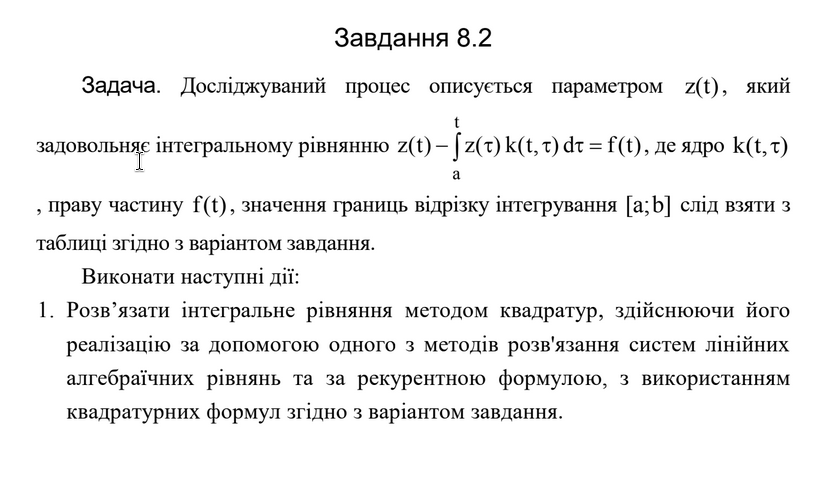

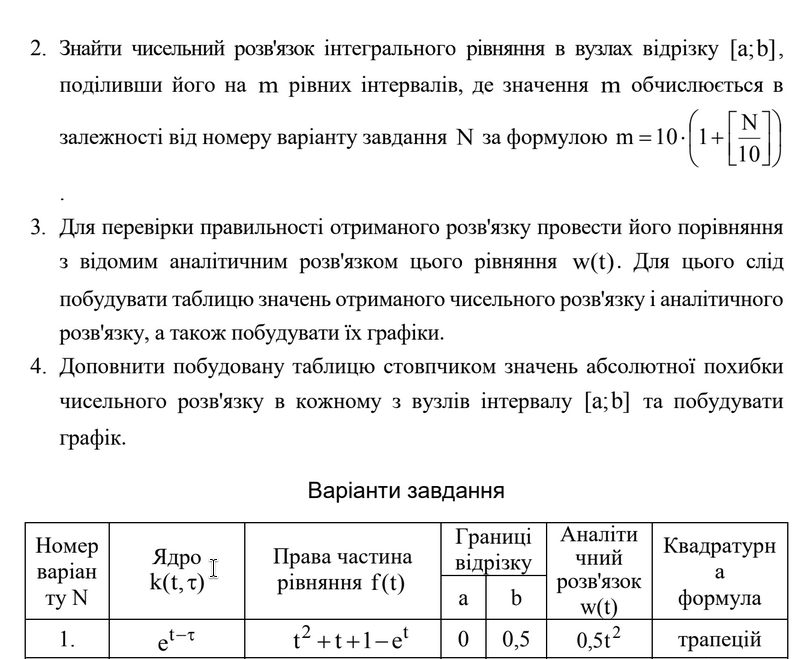

Завдання 8.2 (Варіант 1) - Інтегральне рівняння Вольтерри
   Вузол t  Чисельний розв'язок z(t)  Аналітичний розв'язок w(t)  Абсолютна похибка
0.00000000                0.00000000                  0.00000000         0.00000000
0.05000000                0.00126041                  0.00125000         0.00001041
0.10000000                0.00502086                  0.00500000         0.00002086
0.15000000                0.01128135                  0.01125000         0.00003135
0.20000000                0.02004194                  0.02000000         0.00004194
0.25000000                0.03130266                  0.03125000         0.00005266
0.30000000                0.04506355                  0.04500000         0.00006355
0.35000000                0.06132465                  0.06125000         0.00007465
0.40000000                0.08008601                  0.08000000         0.00008601
0.45000000                0.10134769                  0.10125000         0.00009769
0.50000000        

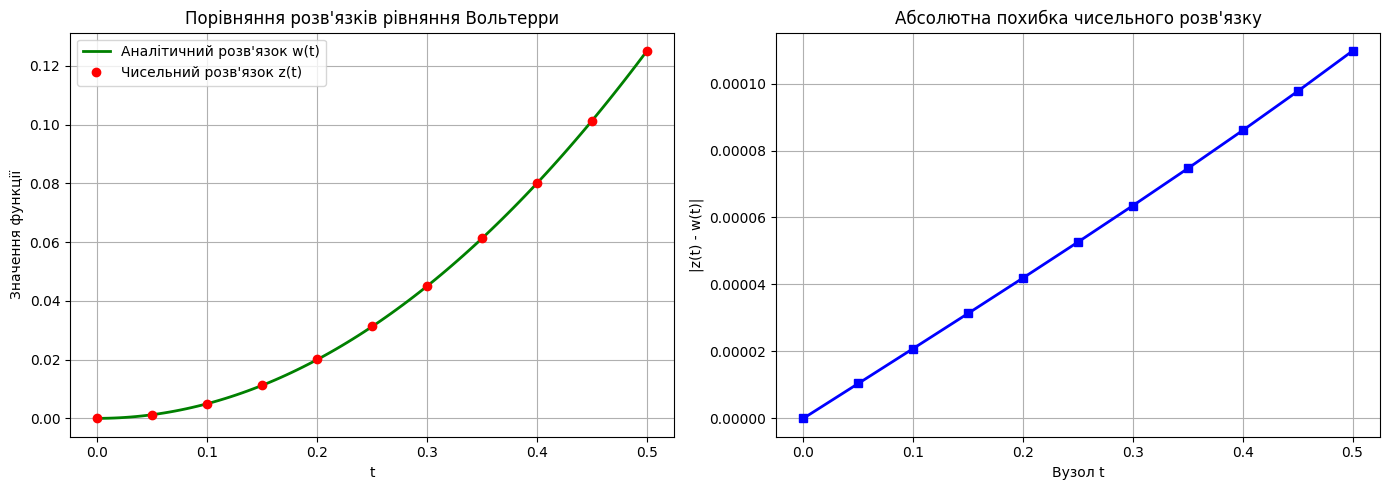

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ==========================================
# Вхідні дані (Завдання 8.2, Варіант 1)
# ==========================================
n_var = 1
m = 10 * (1 + n_var // 10)  # Кількість інтервалів (m = 10)
a = 0.0
b = 0.5
h = (b - a) / m             # Крок сітки

def k_func(t, tau):
    """Ядро рівняння"""
    return np.exp(t - tau)

def f_func(t):
    """Права частина рівняння"""
    return t**2 + t + 1 - np.exp(t)

def w_exact(t):
    """Відомий аналітичний розв'язок"""
    return 0.5 * t**2

# ==========================================
# 1. Формування сітки та СЛАР (Метод трапецій)
# ==========================================
t_nodes = np.linspace(a, b, m + 1)

# Ініціалізуємо матрицю A та вектор правої частини F
A = np.zeros((m + 1, m + 1))
F = f_func(t_nodes)

# Заповнюємо матрицю для рівняння Вольтерри згідно з формулою трапецій
for i in range(m + 1):
    for j in range(i + 1):
        if i == 0 and j == 0:
            # У точці t=0 інтеграл дорівнює нулю, тому z(0) = f(0)
            A[i, j] = 1.0  
        elif j == i:
            # Діагональний елемент (крайня права точка трапеції, вага h/2)
            A[i, j] = 1.0 - (h / 2.0) * k_func(t_nodes[i], t_nodes[j])
        elif j == 0:
            # Крайня ліва точка трапеції (вага h/2)
            A[i, j] = -(h / 2.0) * k_func(t_nodes[i], t_nodes[j])
        else:
            # Внутрішні точки (вага h)
            A[i, j] = -h * k_func(t_nodes[i], t_nodes[j])

# ==========================================
# 2. Розв'язання рівняння та обчислення похибки
# ==========================================
# Розв'язуємо нижньотрикутну матрицю (це математично еквівалентно рекурентній формулі)
z_num = np.linalg.solve(A, F)

# Аналітичний розв'язок для порівняння
w_ana = w_exact(t_nodes)

# Абсолютна похибка
abs_error = np.abs(z_num - w_ana)

# ==========================================
# 3. Створення порівняльної таблиці
# ==========================================
df = pd.DataFrame({
    "Вузол t": t_nodes,
    "Чисельний розв'язок z(t)": z_num,
    "Аналітичний розв'язок w(t)": w_ana,
    "Абсолютна похибка": abs_error
})

print("Завдання 8.2 (Варіант 1) - Інтегральне рівняння Вольтерри")
print("=" * 85)
# Виводимо таблицю з високою точністю
print(df.to_string(index=False, float_format="{:.8f}".format))
print("=" * 85)

# ==========================================
# 4. Побудова графіків
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Графік 1: Порівняння розв'язків
t_smooth = np.linspace(a, b, 100)
ax1.plot(t_smooth, w_exact(t_smooth), 'g-', linewidth=2, label='Аналітичний розв\'язок w(t)')
ax1.plot(t_nodes, z_num, 'ro', markersize=6, label='Чисельний розв\'язок z(t)')

ax1.set_title('Порівняння розв\'язків рівняння Вольтерри')
ax1.set_xlabel('t')
ax1.set_ylabel('Значення функції')
ax1.legend()
ax1.grid(True)

# Графік 2: Абсолютна похибка
ax2.plot(t_nodes, abs_error, 'b-s', linewidth=2, markersize=6)
ax2.set_title('Абсолютна похибка чисельного розв\'язку')
ax2.set_xlabel('Вузол t')
ax2.set_ylabel('|z(t) - w(t)|')
ax2.grid(True)

plt.tight_layout()
plt.show()